In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("ad_click_dataset.csv")
df.head(3)

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,670,User670,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,3044,User3044,NaN,Male,Desktop,Top,NaN,NaN,1
2,5912,User5912,41.0,Non-Binary,NaN,Side,Education,Night,1


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                10000 non-null  int64  
 1   full_name         10000 non-null  object 
 2   age               5234 non-null   float64
 3   gender            5307 non-null   object 
 4   device_type       8000 non-null   object 
 5   ad_position       8000 non-null   object 
 6   browsing_history  5218 non-null   object 
 7   time_of_day       8000 non-null   object 
 8   click             10000 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 703.3+ KB


In [178]:
df.describe()

,id,age,click
count,10000.000000,5234.000000,10000.000000
mean,5060.211400,40.197363,0.650000
std,2861.758265,13.126420,0.476993
min,5.000000,18.000000,0.000000
25%,2529.000000,29.000000,0.000000
50%,5218.000000,39.500000,1.000000
75%,7466.000000,52.000000,1.000000
max,10000.000000,64.000000,1.000000


In [179]:
df.isnull().sum()

id                     0
full_name              0
age                 4766
gender              4693
device_type         2000
ad_position         2000
browsing_history    4782
time_of_day         2000
click                  0
dtype: int64

In [180]:
df=df.dropna(subset='gender')

In [181]:
df.tail(3)

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
9996,7843,User7843,NaN,Female,Desktop,Bottom,Entertainment,NaN,0
9997,3914,User3914,NaN,Male,Mobile,Side,NaN,Morning,0
9999,3056,User3056,44.0,Male,Tablet,Top,Social Media,Morning,0


In [182]:
df['click'].value_counts()

click
1    3449
0    1858
Name: count, dtype: int64

<Axes: xlabel='time_of_day', ylabel='click'>

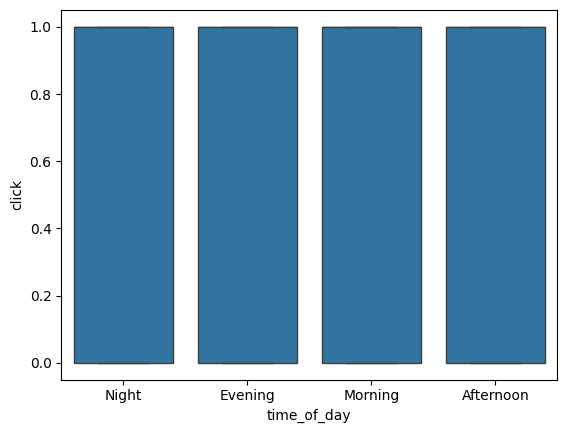

In [183]:
sns.boxplot(x=df['time_of_day'],y=df['click'])

<Axes: xlabel='click', ylabel='count'>

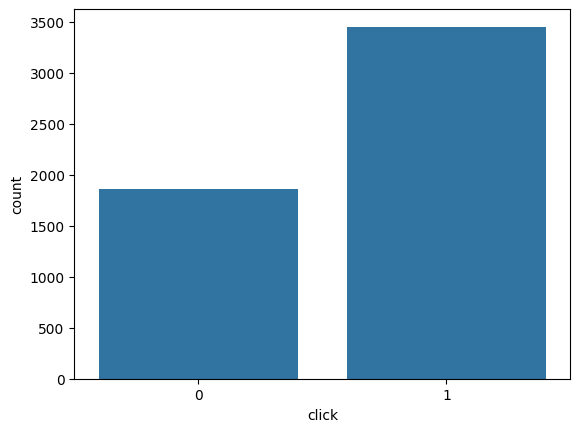

In [184]:
sns.countplot(x='click',data=df)

In [185]:
for col in ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']:
    print(df[col].value_counts())

gender
Female        1834
Male          1810
Non-Binary    1663
Name: count, dtype: int64
device_type
Mobile     1476
Desktop    1431
Tablet     1358
Name: count, dtype: int64
ad_position
Bottom    1513
Top       1419
Side      1289
Name: count, dtype: int64
browsing_history
Entertainment    633
Shopping         571
News             558
Social Media     550
Education        539
Name: count, dtype: int64
time_of_day
Evening      1105
Morning      1104
Night        1037
Afternoon    1020
Name: count, dtype: int64


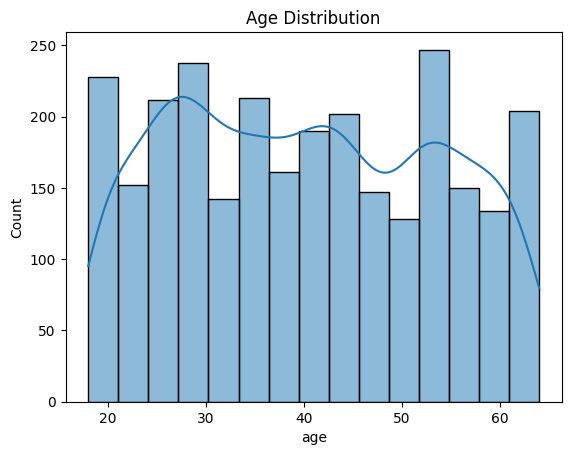

In [186]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

In [187]:
# 
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# ---------------- CLEANING ---------------- #
df = df.drop(['id', 'full_name'], axis=1)

# Save median
age_median = df['age'].median()
df['age'].fillna(age_median, inplace=True)

for col in ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']:
    df[col].fillna('Unknown', inplace=True)

# ---------------- FEATURE ENGINEERING ---------------- #

def age_group(age):
    if age < 25:
        return "young"
    elif age < 40:
        return "adult"
    else:
        return "senior"

df['age_group'] = df['age'].apply(age_group)

df['device_ad'] = df['device_type'] + "_" + df['ad_position']

time_map = {
    'Morning': 0,
    'Afternoon': 1,
    'Evening': 2,
    'Night': 3,
    'Unknown': -1
}
df['time_of_day'] = df['time_of_day'].map(time_map)

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Interaction
if 'device_type_Mobile' in df.columns:
    df['age_device'] = df['age'] * df['device_type_Mobile']
else:
    df['age_device'] = 0

df = df.astype(int)

# ---------------- SPLIT ---------------- #
X = df.drop('click', axis=1)
y = df['click']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- MODEL ---------------- #
params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=params,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

# ---------------- SAVE EVERYTHING ---------------- #
joblib.dump(best_model, "model.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")
joblib.dump(age_median, "age_median.pkl")

C:\Users\malik\AppData\Local\Temp\ipykernel_14128\4013757930.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(age_median, inplace=True)
C:\Users\malik\AppData\Local\Temp\ipykernel_14128\4013757930.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

['age_median.pkl']

In [188]:
import pandas as pd
import joblib

# Load everything
model = joblib.load("model.pkl")
columns = joblib.load("columns.pkl")
age_median = joblib.load("age_median.pkl")

def predict_click(input_data):
    df = pd.DataFrame([input_data])

    # Drop useless
    df = df.drop(['id', 'full_name'], axis=1)

    # Missing values
    df['age'].fillna(age_median, inplace=True)

    for col in ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']:
        df[col].fillna('Unknown', inplace=True)

    # Feature engineering
    def age_group(age):
        if age < 25:
            return "young"
        elif age < 40:
            return "adult"
        else:
            return "senior"

    df['age_group'] = df['age'].apply(age_group)
    df['device_ad'] = df['device_type'] + "_" + df['ad_position']

    time_map = {
        'Morning': 0,
        'Afternoon': 1,
        'Evening': 2,
        'Night': 3,
        'Unknown': -1
    }
    df['time_of_day'] = df['time_of_day'].map(time_map)

    # Encoding
    df = pd.get_dummies(df)

    # Interaction
    if 'device_type_Mobile' in df.columns:
        df['age_device'] = df['age'] * df['device_type_Mobile']
    else:
        df['age_device'] = 0

    df = df.astype(int)

    # Align columns
    for col in columns:
        if col not in df.columns:
            df[col] = 0

    df = df[columns]

    # Prediction
    prob = model.predict_proba(df)[0][1]
    pred = model.predict(df)[0]

    return prob, pred

In [ ]:
sample = {
    "id": 670,
    "full_name": "User670",
    "age": 22.0,
    "gender": None,
    "device_type": "Desktop",
    "ad_position": "Top",
    "browsing_history": "Shopping",
    "time_of_day": "Afternoon"
}

prob, pred = predict_click(sample)

print("Probability:", prob)
print("Prediction:", pred)

Probability: 0.332
Prediction: 0


C:\Users\malik\AppData\Local\Temp\ipykernel_14128\3235989917.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(age_median, inplace=True)
C:\Users\malik\AppData\Local\Temp\ipykernel_14128\3235989917.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [190]:
# df = df.drop(['id', 'full_name'], axis=1)

In [191]:
# df['age'].fillna(df['age'].median(),inplace=True)

In [192]:
# for col in ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']:
    # df[col].fillna('Unknown', inplace=True)

In [193]:
# df.head(4)

In [194]:
# def age_group(age):
#     if age < 25:
#         # return "young"
#     elif age < 40:
#         return "adult"
#     else:
#         return "senior"

# df['age_group'] = df['age'].apply(age_group)
# df = pd.get_dummies(df, columns=['age_group'], drop_first=True)

In [195]:
# df['device_ad'] = df['device_type'] + "_" + df['ad_position']
# df = pd.get_dummies(df, columns=['device_ad'], drop_first=True)

In [196]:
# time_map = {
#     'Morning': 0,
#     'Afternoon': 1,
#     'Evening': 2,
#     'Night': 3,
#     'Unknown': -1
# }

# df['time_of_day'] = df['time_of_day'].map(time_map)

In [197]:
# df.head(3)

In [198]:
# df=pd.get_dummies(df,drop_first=True)
# df = df.astype(int)

In [199]:
# df.head()

In [200]:
# df['age_device'] = df['age'] * df['device_type_Mobile']

In [201]:
# df.columns


In [202]:
# X = df.drop('click', axis=1)
# y = df['click']

In [203]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

In [204]:
# from sklearn.ensemble import RandomForestClassifier

# model = RandomForestClassifier(random_state=42)
# model.fit(X_train, y_train)

In [205]:
# y_pred = model.predict(X_test)
# y_prob = model.predict_proba(X_test)[:, 1]   # important for ROC

In [206]:

# from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))
# print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [207]:
# import pandas as pd
# import matplotlib.pyplot as plt

# importance = pd.Series(model.feature_importances_, index=X.columns)
# importance = importance.sort_values(ascending=True)

# importance.tail(15).plot(kind='barh', figsize=(10,6))
# plt.title("Top Feature Importance")
# plt.show()

In [208]:
# model2 = RandomForestClassifier(class_weight='balanced', random_state=42)
# model2.fit(X_train, y_train)

In [209]:
# y_pred2 = model2.predict(X_test)
# y_prob2 = model2.predict_proba(X_test)[:, 1] 
# from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# print(confusion_matrix(y_test, y_pred2))
# print(classification_report(y_test, y_pred2))
# print("ROC-AUC:", roc_auc_score(y_test, y_prob2))

In [210]:
# # hyper
# from sklearn.model_selection import RandomizedSearchCV
# # Tries RANDOM combinations
# # Example:
# # Instead of 20 combinations → tries only 10 randomly
# # GridSearch → checks every shop in market
# # RandomSearch → checks few random shops (faster)
# params = {
#     'n_estimators': [200, 300, 500],
#     'max_depth': [10, 20, 30, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]  
# }

# search = RandomizedSearchCV(
#     RandomForestClassifier(class_weight='balanced'),
#     param_distributions=params,
#     n_iter=10,
#     cv=3,
#     scoring='roc_auc',
#     random_state=42
# )

# search.fit(X_train, y_train)

# best_model = search.best_estimator_

In [211]:
# y_pred = best_model.predict(X_test)
# y_prob = best_model.predict_proba(X_test)[:, 1]

In [212]:
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score,
#     confusion_matrix,
#     classification_report
# )

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall:", recall_score(y_test, y_pred))
# print("F1 Score:", f1_score(y_test, y_pred))
# print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [213]:
# from sklearn.metrics import roc_curve
# import matplotlib.pyplot as plt

# fpr, tpr, _ = roc_curve(y_test, y_prob)

# plt.plot(fpr, tpr)
# plt.plot([0,1], [0,1], linestyle='--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.show()

In [214]:
# import joblib
# joblib.dump(best_model,"model.pkl")
# joblib.dump(X.columns.tolist(), "columns.pkl")

In [215]:
# import pandas as pd
# import joblib

# model = joblib.load("model.pkl")
# columns = joblib.load("columns.pkl")
# # 5912,User5912,41.0,Non-Binary,,Side,Education,Night,1

# input_data = {
#     "id":5912,
#     "full_name": "User5912",
#     "age": 41.0,
#     "gender": "Non-Binary",
#     "device_type": "",
#     "ad_position": "Side",
#     "browsing_history": "Education",
#     "time_of_day": "Night"
# }

# # Convert to DataFrame
# df = pd.DataFrame([input_data])

# df = df.drop(['id', 'full_name'], axis=1)

# df['age'].fillna(df['age'].median(), inplace=True)

# for col in ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']:
#     df[col].fillna('Unknown', inplace=True)

# def age_group(age):
#     if age < 25:
#         return "young"
#     elif age < 40:
#         return "adult"
#     else:
#         return "senior"

# df['age_group'] = df['age'].apply(age_group)

# df['device_ad'] = df['device_type'] + "_" + df['ad_position']

# df = pd.get_dummies(df)


# for col in columns:
#     if col not in df.columns:
#         df[col] = 0

# df = df[columns]



# prob = model.predict_proba(df)[:, 1][0]
# pred = model.predict(df)[0]

# print("Click Probability:", prob)
# print("Prediction:", pred)

In [216]:
# df = df.drop(['id', 'full_name'], axis=1)
# df['age'].fillna(df['age'].median(),inplace=True)
# for col in ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']:
#     df[col].fillna('Unknown', inplace=True)

# def age_group(age):
#     if age < 25:
#         return "young"
#     elif age < 40:
#         return "adult"
#     else:
#         return "senior"

# df['age_group'] = df['age'].apply(age_group)
# df = pd.get_dummies(df, columns=['age_group'], drop_first=True)


# df['device_ad'] = df['device_type'] + "_" + df['ad_position']
# df = pd.get_dummies(df, columns=['device_ad'], drop_first=True)

# time_map = {
#     'Morning': 0,
#     'Afternoon': 1,
#     'Evening': 2,
#     'Night': 3,
#     'Unknown': -1
# }

# df['time_of_day'] = df['time_of_day'].map(time_map)

# df=pd.get_dummies(df,drop_first=True)
# df = df.astype(int)
# df['age_device'] = df['age'] * df['device_type_Mobile']

# X = df.drop('click', axis=1)
# y = df['click']

# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )
# # hyper
# from sklearn.model_selection import RandomizedSearchCV
# # Tries RANDOM combinations
# # Example:
# # Instead of 20 combinations → tries only 10 randomly
# # GridSearch → checks every shop in market
# # RandomSearch → checks few random shops (faster)
# params = {
#     'n_estimators': [200, 300, 500],
#     'max_depth': [10, 20, 30, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]  
# }

# search = RandomizedSearchCV(
#     RandomForestClassifier(class_weight='balanced'),
#     param_distributions=params,
#     n_iter=10,
#     cv=3,
#     scoring='roc_auc',
#     random_state=42
# )

# search.fit(X_train, y_train)

# best_model = search.best_estimator_

# y_pred = best_model.predict(X_test)
# y_prob = best_model.predict_proba(X_test)[:, 1]